In [5]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv


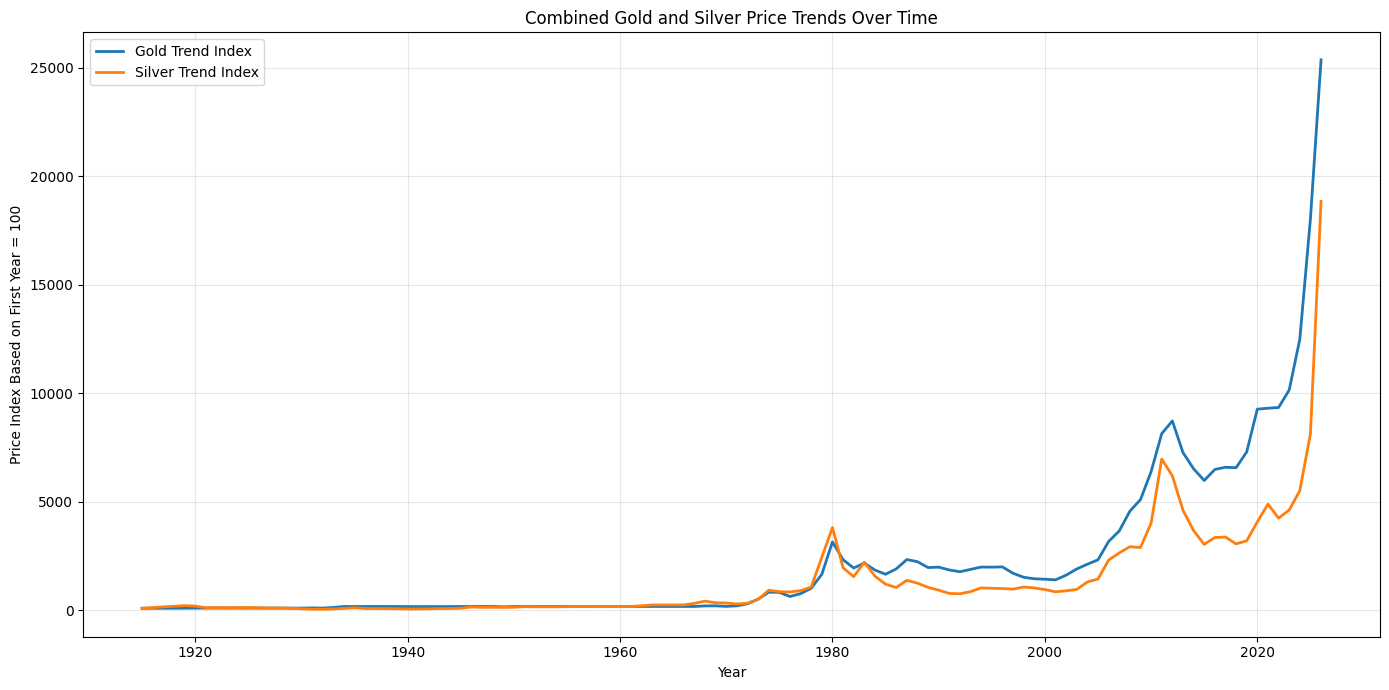

,Year,Gold_Average_Price,Silver_Average_Price,Gold_Index,Silver_Index
0,1915,19.25,0.51,100.000000,100.000000
1,1916,19.47,0.67,101.142857,131.372549
2,1917,19.66,0.84,102.129870,164.705882
3,1918,19.84,0.98,103.064935,192.156863
4,1919,20.03,1.13,104.051948,221.568627
5,1920,20.63,1.03,107.168831,201.960784
6,1921,20.69,0.63,107.480519,123.529412
7,1922,20.84,0.68,108.259740,133.333333
8,1923,20.75,0.65,107.792208,127.450980
9,1924,20.78,0.67,107.948052,131.372549


,Year,Gold_Average_Price,Silver_Average_Price,Gold_Index,Silver_Index
102,2017,1269.337500,17.235517,6593.961039,3379.513072
103,2018,1265.600000,15.637617,6574.545455,3066.199346
104,2019,1405.325000,16.361800,7300.389610,3208.196078
105,2020,1784.657500,20.796133,9270.948052,4077.673203
106,2021,1792.731667,24.968133,9312.891775,4895.712418
107,2022,1798.956575,21.671767,9345.228961,4249.366013
108,2023,1953.688517,23.579675,10149.031255,4623.465686
109,2024,2404.577567,28.128033,12491.312035,5515.300654
110,2025,3472.540975,41.501500,18039.173896,8137.549020
111,2026,4881.619800,96.083200,25359.063896,18839.843137


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

gold_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv")
silver_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv")

gold_df["Date"] = pd.to_datetime(gold_df["Date"], dayfirst=True, errors="coerce")
silver_df["Date"] = pd.to_datetime(silver_df["Date"], dayfirst=True, errors="coerce")

gold_df = gold_df.dropna(subset=["Date", "Value"])
silver_df = silver_df.dropna(subset=["Date", "Value"])

gold_df["Year"] = gold_df["Date"].dt.year
silver_df["Year"] = silver_df["Date"].dt.year

gold_yearly = gold_df.groupby("Year")["Value"].mean().reset_index()
silver_yearly = silver_df.groupby("Year")["Value"].mean().reset_index()

gold_yearly.columns = ["Year", "Gold_Average_Price"]
silver_yearly.columns = ["Year", "Silver_Average_Price"]

combined_df = pd.merge(gold_yearly, silver_yearly, on="Year", how="inner")

combined_df["Gold_Index"] = (combined_df["Gold_Average_Price"] / combined_df["Gold_Average_Price"].iloc[0]) * 100
combined_df["Silver_Index"] = (combined_df["Silver_Average_Price"] / combined_df["Silver_Average_Price"].iloc[0]) * 100

combined_df.to_csv("gold_silver_combined_trend_table.csv", index=False)

plt.figure(figsize=(14, 7))
plt.plot(combined_df["Year"], combined_df["Gold_Index"], label="Gold Trend Index", linewidth=2)
plt.plot(combined_df["Year"], combined_df["Silver_Index"], label="Silver Trend Index", linewidth=2)

plt.title("Combined Gold and Silver Price Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Price Index Based on First Year = 100")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("gold_silver_combined_trend_chart.pdf", format="pdf", bbox_inches="tight")
plt.show()

display(combined_df.head(10))
display(combined_df.tail(10))